# Модель предсказания возрастной категории пользователей интернет сервисов

### Общая информация
- Заказчик проекта — крупная IT-компания, которая управляет группой популярных интернет-сервисов.
- Необходимо проанализировать цифровой след пользователей, чтобы предсказать их возрастную категорию.
- Разработанный инструмент будет использоваться маркетологами: поможет показывать рекламу на целевую аудиторию определённого возраста и снизить риски показа рекламы для взрослых несовершеннолетним.


### Бизнес-задача
- повышение эффективности рекламных кампаний за счет точного таргетинга по возрастным группам и снижения рисков показа рекламы для взрослых несовершеннолетним.

### Цель:
- разработать модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его возрастную категорию


### ML задача

Вид задачи:
- тип задачи: обучение с учителем
- подтип: многоклассовая классификация

Целевая переменная:
- age_category - категориальная переменная, закодированная как:
    - 0: младше 18 лет
    - 1: 18-25 лет
    - 2: 26-40 лет
    - 3: 41-55 лет
    - 4: более 55 лет

Особенности:
- признаки могут иметь нелинейные связи с целевыми классами
- F1-мера - основная метрика, precision и recall - вспомогательные
- Модель нужно оценить одинаково по всем классам, даже если один из них встречается редко. (макро усреднение)

## 1. Подготовка среды, библиотек, загрузка данных

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from phik import phik_matrix
import joblib
from typing import Optional
from functools import reduce
from typing import Optional
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import joblib
from sklearn.preprocessing import TargetEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from scipy import sparse
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance


In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### Загрузка данных

In [4]:
data_paths = [
    'https://code.s3.yandex.net/datasets/ds_s13_users.csv',
    'https://code.s3.yandex.net/datasets/ds_s13_visits.csv',
    'https://code.s3.yandex.net/datasets/ads_activity.csv',
    'https://code.s3.yandex.net/datasets/surf_depth.csv',
    'https://code.s3.yandex.net/datasets/primary_device.csv',
    'https://code.s3.yandex.net/datasets/cloud_usage.csv'
]

In [5]:
def read_show_info(path: str) -> pd.DataFrame:
    """Чтение csv файла по ссылке и отображение базовой информации о датасете"""

    df = pd.read_csv(path)
    display(df.info(), df.head(5))

    return df
    

In [6]:
df_users = read_show_info(data_paths[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


None

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


In [7]:
df_visits = read_show_info(data_paths[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


None

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [8]:
df_ads_activity = read_show_info(data_paths[2])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


None

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [9]:
df_surf_depth = read_show_info(data_paths[3])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


None

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [10]:
df_primary_device = read_show_info(data_paths[4])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


None

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


In [11]:
df_cloud_usage = read_show_info(data_paths[5])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


None

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


Итог:
- данные загружены корректно

## 2. Исследовательский анализ данных

### Базовая информация

In [12]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [13]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [14]:
data_frames = [df_users, df_ads_activity, df_cloud_usage, df_surf_depth, df_visits, df_primary_device]
names = ['users', 'ads_activity', 'cloud_usage', 'surf_depth', 'visits', 'primary_device']

#### Анализ таблиц по отдельности

In [15]:
for name, data_frame in zip(names, data_frames):
    get_base_df_info(name=name, df=data_frame)

Общая информация о датафрейме users


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


,Метрика,Значение
0,Строк,5913.00
1,Колонок,2.00
2,"Явных дубликатов, %",1.47
3,Категориальных колонок,1.00
4,Числовых колонок,1.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
user_id,object,0,0.0,5826
age_category,int64,0,0.0,5


...

Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
user_id,object,0,0.0,5669
primary_device,object,0,0.0,4


Типы колонок


,Категориальные колонки,Числовые колонки
0,user_id,NaN
1,primary_device,NaN


--------------------------------------------------


#### Анализ:



Данные представлены в виде 6 таблиц: 
1. users.

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - age_category — возрастная категория пользователя, этот показатель модель должна научиться предсказывать

    Анализ:
    - Строк	5913, Колонок	2
    - 1.47% явных дублей 
    - Категориальных колонок 1: user_id,
    - Числовых колонок	1: age_category
    - age_category - 5 категорий
    - пропусков нет

    Итог:
    - явных дублей мало, можно удалить

2. visits

    Состав:
    - date — дата посещения сайта.
    - daytime — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
    - session_id — уникальный идентификатор сессии. 
    - user_id — уникальный идентификатор пользователя.
    - website_category — анонимизированная категория сайта. 

    Анализ:
    - Строк	1065745, Колонок	5
    - 1.48% явных дублей 
    - Категориальных колонок 5: date, daytime, session_id, user_id, website_category
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - явных дублей мало, можно удалить
    - date стоит преобразовать к типу datetime 
    - daytime всего 4 уникальных значения, можно воспользоваться OneHot кодированием
    - website_category уникальных значений 20шт - лучше воспользоваться TargetEncoding, чтобы не раздувать признаковое пространство
    - из признака session_id (уникальный идентификатор сессии) можно получить количество сессий для одного пользователя (user_id). Новый признак session_count может быть полезен, поскольку отражает активность пользователя (насколько часто он пользуется сервисами)

3. ads_activity

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - ads_activity — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.

    Анализ:
    - Строк	5826, Колонок	2
    - 4% явных дублей 
    - Категориальных колонок 2: user_id, ads_activity
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - явных дублей мало, можно удалить
    - признак ads_activity преобразуем в числовой дискретный от 0 до 4 по возрастанию CTR соответственно

4. surf_depth

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - surf_depth — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.

    Анализ:
    - Строк	5715, Колонок	2
    - явных дублей нет
    - Категориальных колонок 2: user_id, surf_depth
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - очистка от дублей не требуется, преобразование типов тоже 
    - уместно преобразовать surf_depth в дискретный числовой признак: 0, 1, 2 в соответствии с степенью глубины

5. primary_device

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - primary_device — информация о типе основного устройства пользователя для выхода в Интернет.

    Анализ:
    - Строк	5669, Колонок	2
    - явных дублей нет
    - Категориальных колонок 2: user_id, primary_device
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - очистка от дублей не требуется, преобразование типов тоже 
    - уникальных значений primary_device меньше 10, уместно использовать OneHot кодирование

6. cloud_usage

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - cloud_usage — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.

    Анализ:
    - Строк	5680, Колонок	2
    - явных дублей нет
    - Категориальных колонок 2: user_id, cloud_usage
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - необходимо преобразовать cloud_usage в int со значениями 0, 1


### Общий итог:

 - данные соответствуют описанию
 - присутстуют малочисленные дубликаты, от которых можно избавиться
 - категориальные переменные стоит закодировать в предобработке: OneHot, если кол-во уникальных значений < 10, иначе Target
 - часть категориальных признаков имеет смысл преобразовать в последовательные числовые дискретные признаки: ads_activity, surf_depth
 - date стоит преобразовать в формат datetime
 - все таблицы можно объединить по общей колонке user_id
 - предложено сформировать новые признаки на основе таблицы visits. После этого session_id можно удалить

### Агрегация информации по таблице visits

Генерация агрегированных признаков для уникальных пользователей 

In [16]:
def create_users_agg_features(df_visits: pd.DataFrame):
    """
    Формирование агрегированных по пользователям признаков на основе датасета visits с колонками:
        - date — дата посещения сайта.
        - daytime — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
        - session_id — уникальный идентификатор сессии. 
        - user_id — уникальный идентификатор пользователя.
        - website_category — анонимизированная категория сайта. 
    """
    df_visits_agg = df_visits['user_id'].drop_duplicates() # датасет для результата

    # самый популярный день недели
    df_visits['week_day'] = pd.to_datetime(df_visits['date']).dt.day_name()
    week_day_mode = df_visits.groupby('user_id')['week_day'].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else None
    ).reset_index(name='week_day_mode')
    df_visits_agg = pd.merge(df_visits_agg, week_day_mode, how='inner', on='user_id')

    # количество сессий у пользователя
    session_count = df_visits.groupby('user_id')['session_id'].count().reset_index(name='session_count')
    df_visits_agg = pd.merge(df_visits_agg, session_count, how='inner', on='user_id')

    # самое популярное время суток у пользователя
    daytime_mode = df_visits.groupby('user_id')['daytime'].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else None
    ).reset_index(name='daytime_mode')
    
    df_visits_agg = pd.merge(df_visits_agg, daytime_mode, how='inner', on='user_id')

    # наиболее и наименее популярные категории у пользователей
    counts = (df_visits
        .groupby(['user_id', 'website_category'])
        .size()
        .unstack(fill_value=0)
    )
    user_website_category_stats = pd.DataFrame({
        'most_popular_website_category': counts.idxmax(axis=1),
        'least_popular_website_category': counts.idxmin(axis=1),
    })
    df_visits_agg = pd.merge(df_visits_agg, user_website_category_stats, how='inner', on='user_id')

    # медианное количество посещений в день
    median_sessions_per_day = df_visits.groupby(
        ['user_id', 'date']
    )['session_id'].count().groupby('user_id').median().reset_index(name='median_sessions_per_day')
    
    df_visits_agg = pd.merge(df_visits_agg, median_sessions_per_day, how='inner', on='user_id')

    # доля посещений пользователя по категориям сайтов
    user_category_counts = df_visits.pivot_table(
        index='user_id',
        columns='website_category',
        aggfunc='size',
        fill_value=0
    )
    user_category_shares = (
        user_category_counts
        .div(user_category_counts.sum(axis=1), axis=0)
        .add_prefix('share_website_category_')
        .reset_index()
    )
    df_visits_agg = pd.merge(df_visits_agg, user_category_shares, how='inner', on='user_id')

    return df_visits_agg
    

Итоговый датасет с информацией о посещениях:

In [17]:
df_visits_agg = create_users_agg_features(df_visits=df_visits)
df_visits_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             5826 non-null   object 
 1   week_day_mode                       5826 non-null   object 
 2   session_count                       5826 non-null   int64  
 3   daytime_mode                        5826 non-null   object 
 4   most_popular_website_category       5826 non-null   object 
 5   least_popular_website_category      5826 non-null   object 
 6   median_sessions_per_day             5826 non-null   float64
 7   share_website_category_Category 01  5826 non-null   float64
 8   share_website_category_Category 02  5826 non-null   float64
 9   share_website_category_Category 03  5826 non-null   float64
 10  share_website_category_Category 04  5826 non-null   float64
 11  share_website_category_Category 05  5826 no

### Формирование общей таблицы 

In [18]:
def create_dataset(names_df_dict: dict[str, pd.DataFrame]):
    """Формирование общего датасета"""

    if names_df_dict.get('visits') is not None:
        df_visits_agg = create_users_agg_features(df_visits=names_df_dict['visits'])
        names_df_dict['visits'] = df_visits_agg

    df_upd = reduce(lambda left, right: pd.merge(left, right, on='user_id', how='outer'), names_df_dict.values())

    return df_upd


In [19]:
data_frames = [df_users, df_ads_activity, df_cloud_usage, df_surf_depth, df_primary_device, df_visits]
names = ['users', 'ads_activity', 'cloud_usage', 'surf_depth', 'primary_device', 'visits']

names_df_dict = {k: v for k, v in zip(names, data_frames)}

In [20]:
df = create_dataset(names_df_dict)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             6146 non-null   object 
 1   age_category                        6146 non-null   int64  
 2   ads_activity                        5908 non-null   object 
 3   cloud_usage                         5991 non-null   object 
 4   surf_depth                          6029 non-null   object 
 5   primary_device                      5982 non-null   object 
 6   week_day_mode                       6146 non-null   object 
 7   session_count                       6146 non-null   int64  
 8   daytime_mode                        6146 non-null   object 
 9   most_popular_website_category       6146 non-null   object 
 10  least_popular_website_category      6146 non-null   object 
 11  median_sessions_per_day             6146 no

#### Анализ пропусков

In [21]:
df.isna().sum() / len(df) * 100

user_id                               0.000000
age_category                          0.000000
ads_activity                          3.872437
cloud_usage                           2.521966
surf_depth                            1.903677
primary_device                        2.668402
week_day_mode                         0.000000
session_count                         0.000000
daytime_mode                          0.000000
most_popular_website_category         0.000000
least_popular_website_category        0.000000
median_sessions_per_day               0.000000
share_website_category_Category 01    0.000000
share_website_category_Category 02    0.000000
share_website_category_Category 03    0.000000
share_website_category_Category 04    0.000000
share_website_category_Category 05    0.000000
share_website_category_Category 06    0.000000
share_website_category_Category 07    0.000000
share_website_category_Category 08    0.000000
share_website_category_Category 09    0.000000
share_website

- пропуски заменим на статистики после разделения датасета

#### Дубли

In [22]:
df.duplicated().sum() / len(df) * 100

np.float64(5.206638464041653)

- сразу чистим от данные от дублей

In [23]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Анализ целевой переменной

In [24]:
target = df['age_category']

In [25]:
# Соотношение классов
target.value_counts() / len(target) * 100

age_category
4    30.312393
2    24.699622
3    21.524202
0    14.641263
1     8.822520
Name: count, dtype: float64

Анализ:
- наблюдается дисбаланс классов в целевой переменной. 
- самый малочисленный класс 1 содержит в 3.5 раза меньше объектов, чем многочисленный класс 4.

Рекомендация:
- использовать стратификацию при разбиении на train/test
- для учета дисбаланса классов необходимо использовать макроусреднение при подсчете метрик качества моделей

### Анализ распределений целевого класса по признакам

In [26]:
cat_cols_names, num_cols_names = get_cat_num_cols(df=df)
cat_cols_names, num_cols_names

(['user_id',
  'ads_activity',
  'cloud_usage',
  'surf_depth',
  'primary_device',
  'week_day_mode',
  'daytime_mode',
  'most_popular_website_category',
  'least_popular_website_category'],
 ['age_category',
  'session_count',
  'median_sessions_per_day',
  'share_website_category_Category 01',
  'share_website_category_Category 02',
  'share_website_category_Category 03',
  'share_website_category_Category 04',
  'share_website_category_Category 05',
  'share_website_category_Category 06',
  'share_website_category_Category 07',
  'share_website_category_Category 08',
  'share_website_category_Category 09',
  'share_website_category_Category 10',
  'share_website_category_Category 11',
  'share_website_category_Category 12',
  'share_website_category_Category 13',
  'share_website_category_Category 14',
  'share_website_category_Category 15',
  'share_website_category_Category 16',
  'share_website_category_Category 17',
  'share_website_category_Category 18',
  'share_website_cate

Распределения по целевому классу

In [27]:
def plot_bar_target_class(
    df: pd.DataFrame, target_name: str, cat_col: str, 
    desired_order: Optional[list[str]] = None, sort_target: Optional[int] = None
):
    """Столбчатые диаграммы распрелелений по целевым классам для категориальных признаков"""

    df_chain_unstack = df.groupby(cat_col)[target_name].value_counts(normalize=True).unstack(fill_value=0)

    if sort_target is not None:
        df_chain_unstack = df_chain_unstack.sort_values(by=sort_target)

    if desired_order:
        df_chain_unstack = df_chain_unstack.reindex(desired_order)

    df_chain_unstack.plot(kind='bar')

    plt.title(f'Доля целевых классов для признака {cat_col}') 
    plt.ylabel('Доля') 
    plt.xlabel(cat_col) 
    plt.xticks(rotation=45)  
    plt.legend()  

    plt.show()

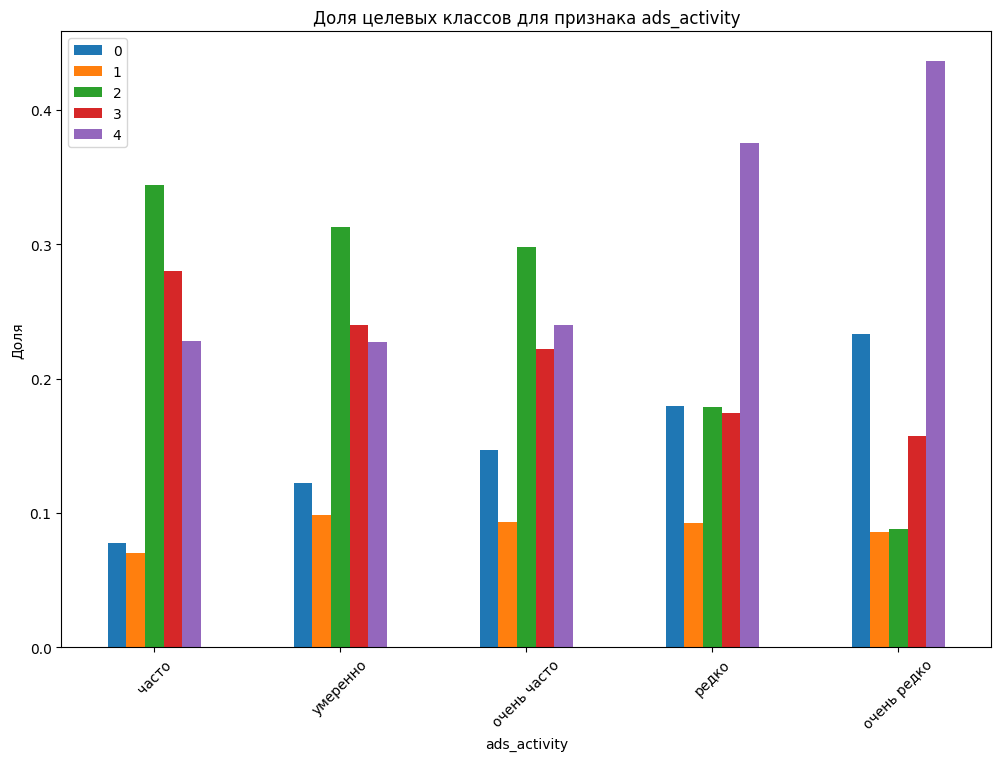

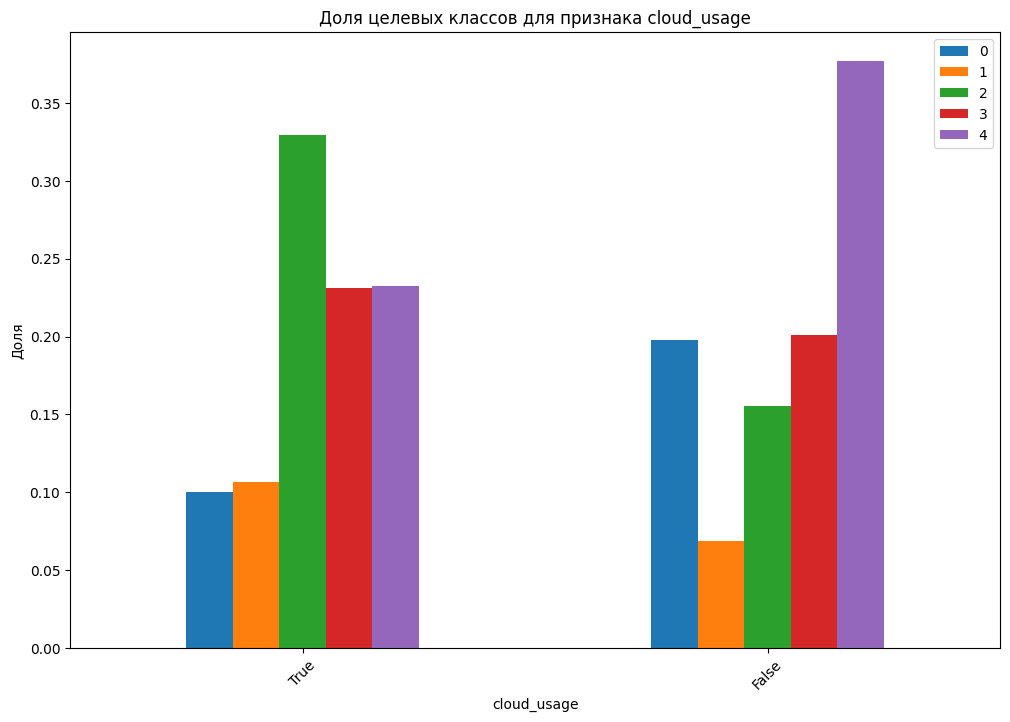

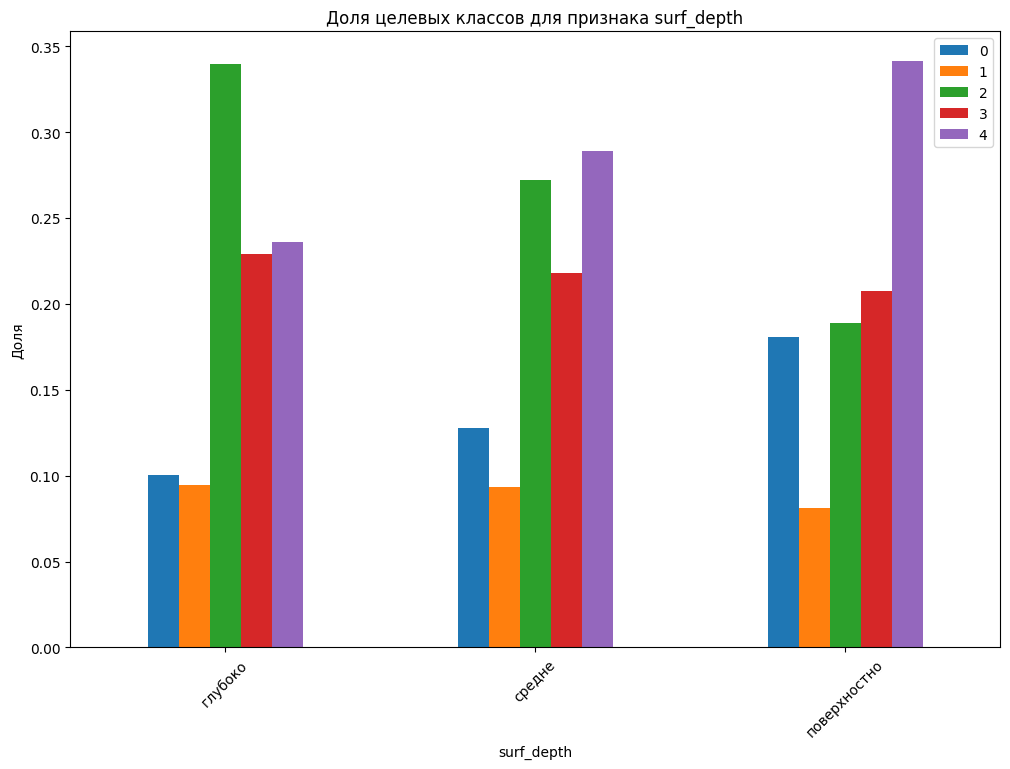

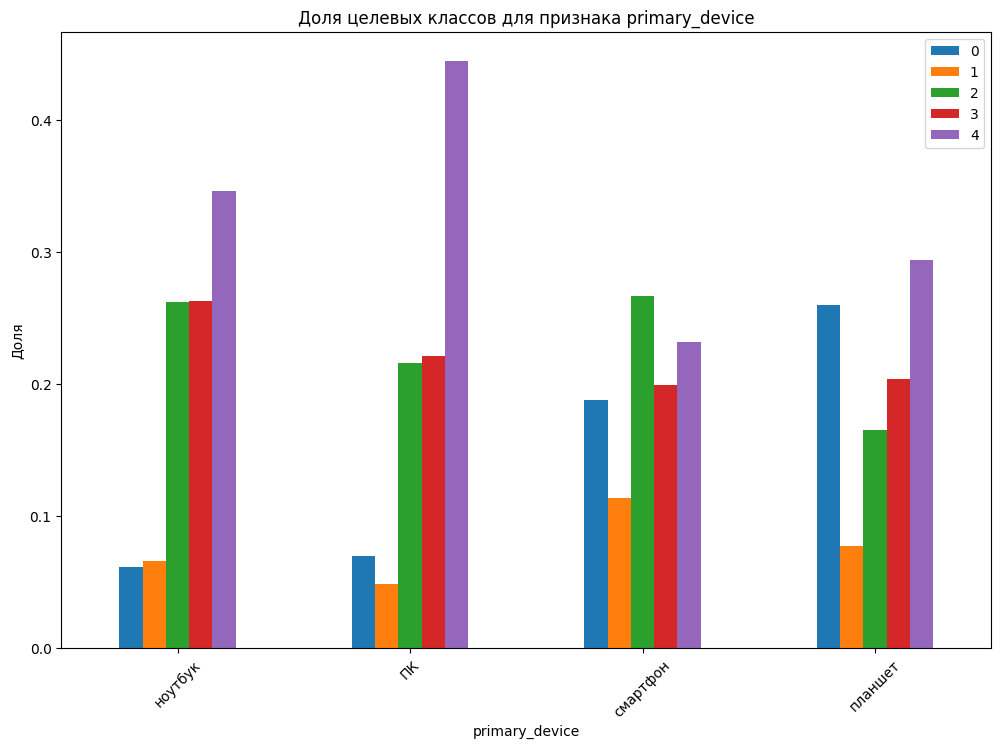

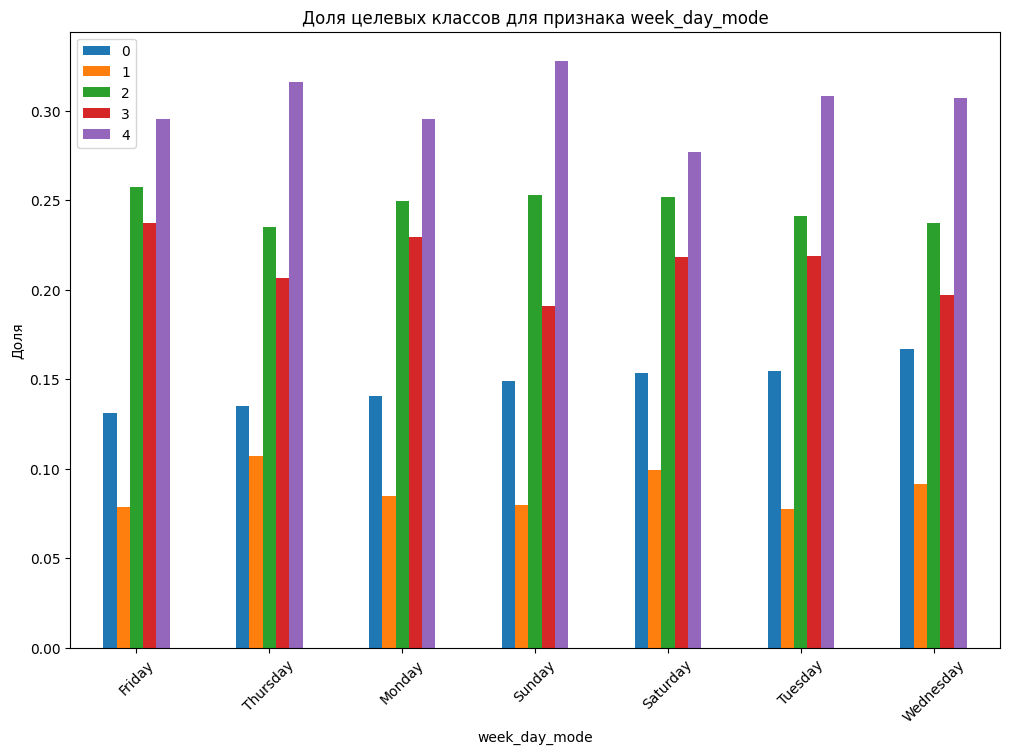

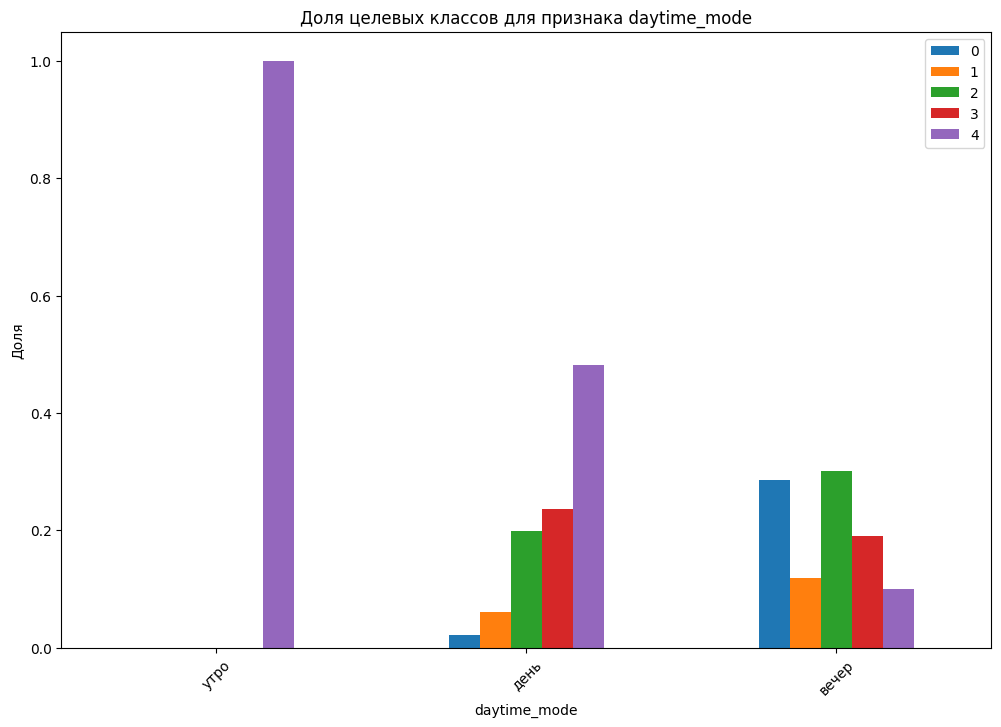

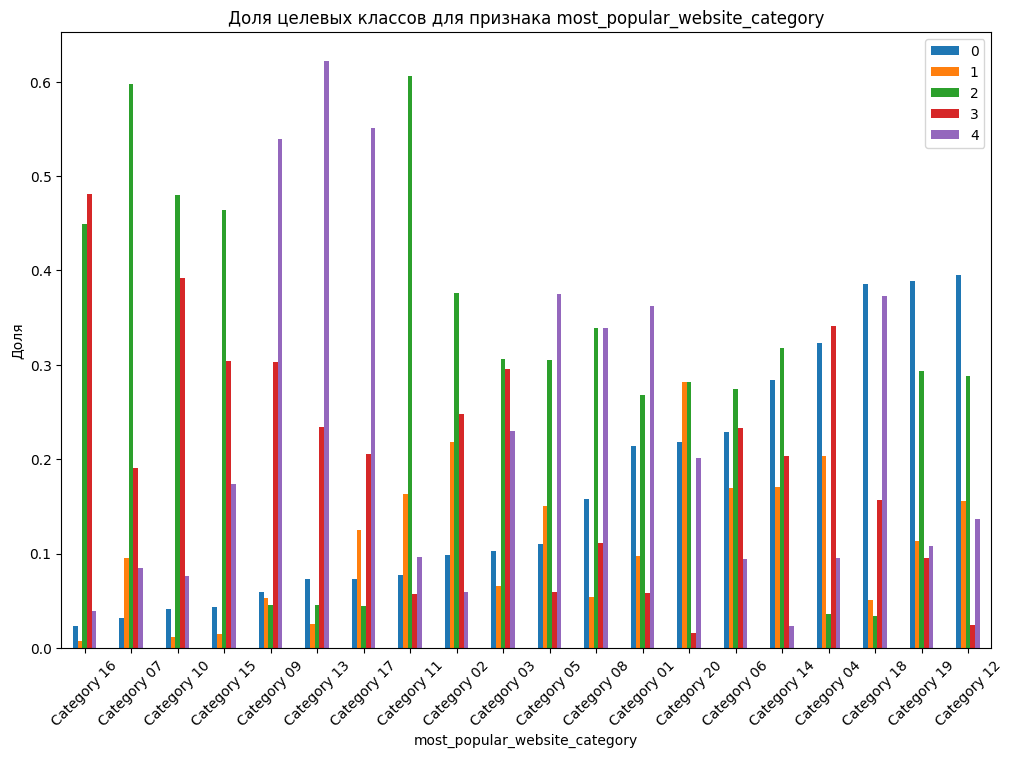

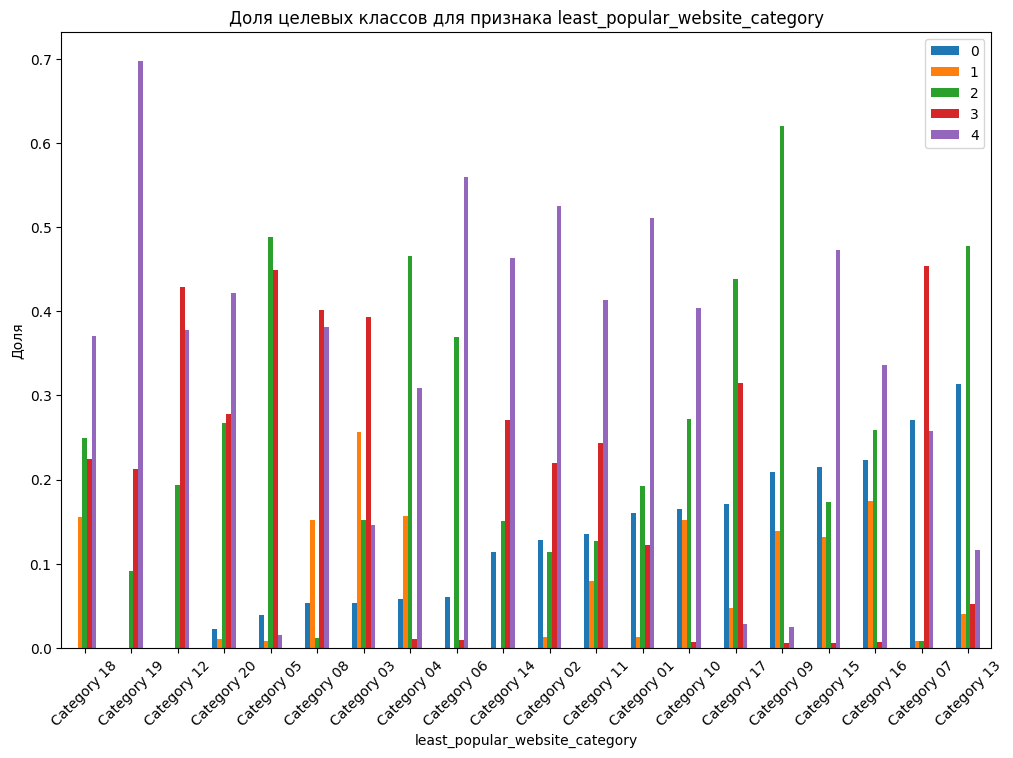

In [28]:
cat_cols_names = cat_cols_names[1:]
for name in cat_cols_names:
    plot_bar_target_class(df=df, target_name='age_category', cat_col=name, sort_target=0)

Анализ:
- доли классов существенно варьируются по данным признакам

Итог:
- признаки потенциально полезны для дальнейшего анализа

### Распределения таргета по числовым признакам

In [29]:
num_cols_names

['age_category',
 'session_count',
 'median_sessions_per_day',
 'share_website_category_Category 01',
 'share_website_category_Category 02',
 'share_website_category_Category 03',
 'share_website_category_Category 04',
 'share_website_category_Category 05',
 'share_website_category_Category 06',
 'share_website_category_Category 07',
 'share_website_category_Category 08',
 'share_website_category_Category 09',
 'share_website_category_Category 10',
 'share_website_category_Category 11',
 'share_website_category_Category 12',
 'share_website_category_Category 13',
 'share_website_category_Category 14',
 'share_website_category_Category 15',
 'share_website_category_Category 16',
 'share_website_category_Category 17',
 'share_website_category_Category 18',
 'share_website_category_Category 19',
 'share_website_category_Category 20']

In [30]:
def feat_by_category_hist(
    data: pd.DataFrame, feat_name: str, 
    category: str, units_x: str
):
    """Гистограмма распределения признака по категорям"""
    sns.histplot(data=data, x=feat_name, hue=category, kde=True, stat='density')
    plt.xlabel(units_x)
    plt.ylabel('плотность')
    plt.title(f'Распределение признака {feat_name} по классам {category}')
    plt.grid()
    plt.show()

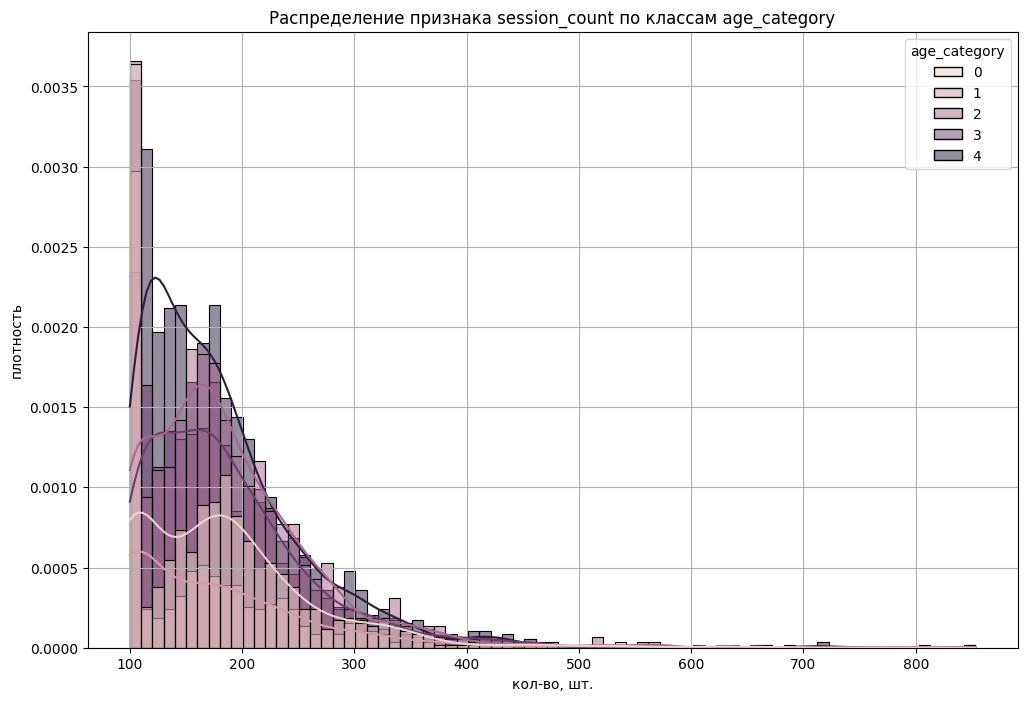

In [31]:
feat_by_category_hist(data=df, feat_name='session_count', category='age_category', units_x='кол-во, шт.')

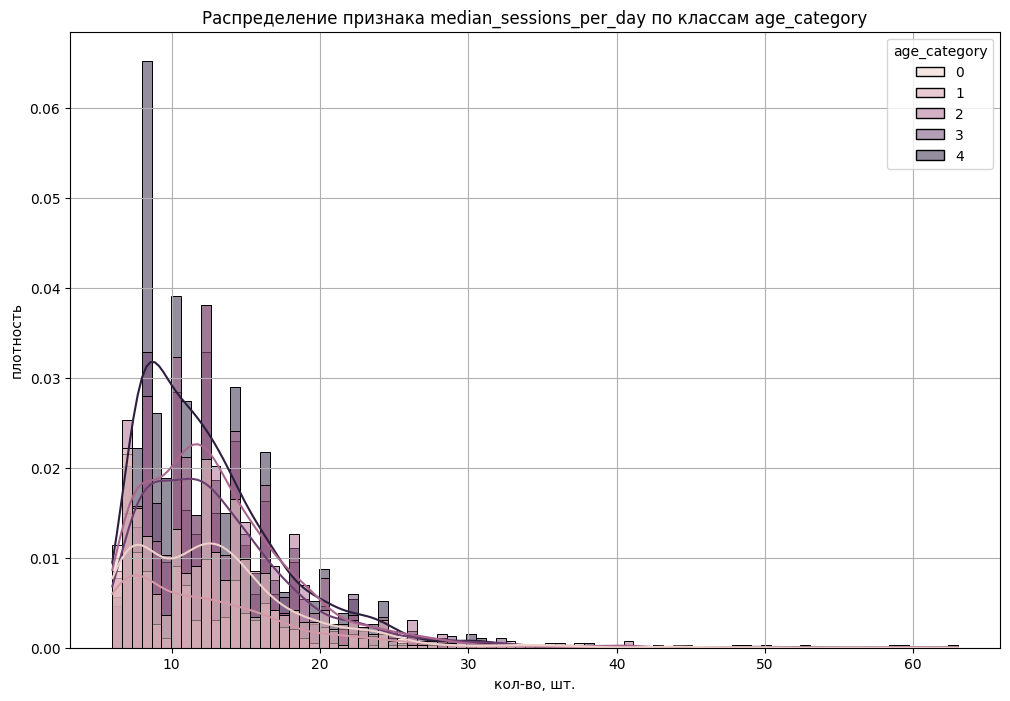

In [32]:
feat_by_category_hist(data=df, feat_name='median_sessions_per_day', category='age_category', units_x='кол-во, шт.')

Анализ:
- общий вид распределения признаков смещен. Распределения имеют длинные хвосты.
- распределение среди более молодых смещено вправо: они более активные

Рекомендация:
- применить лог преобразование к признакам, чтобы симметризовать распределения

#### Корреляционный анализ

In [33]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреяций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [34]:
cat_cols_to_analyse = [name for name in cat_cols_names if len(df[name].unique()) < 100]
corr_matrix = get_corr_matrix(data=df, feat_cols=num_cols_names + cat_cols_names, num_cols=num_cols_names)

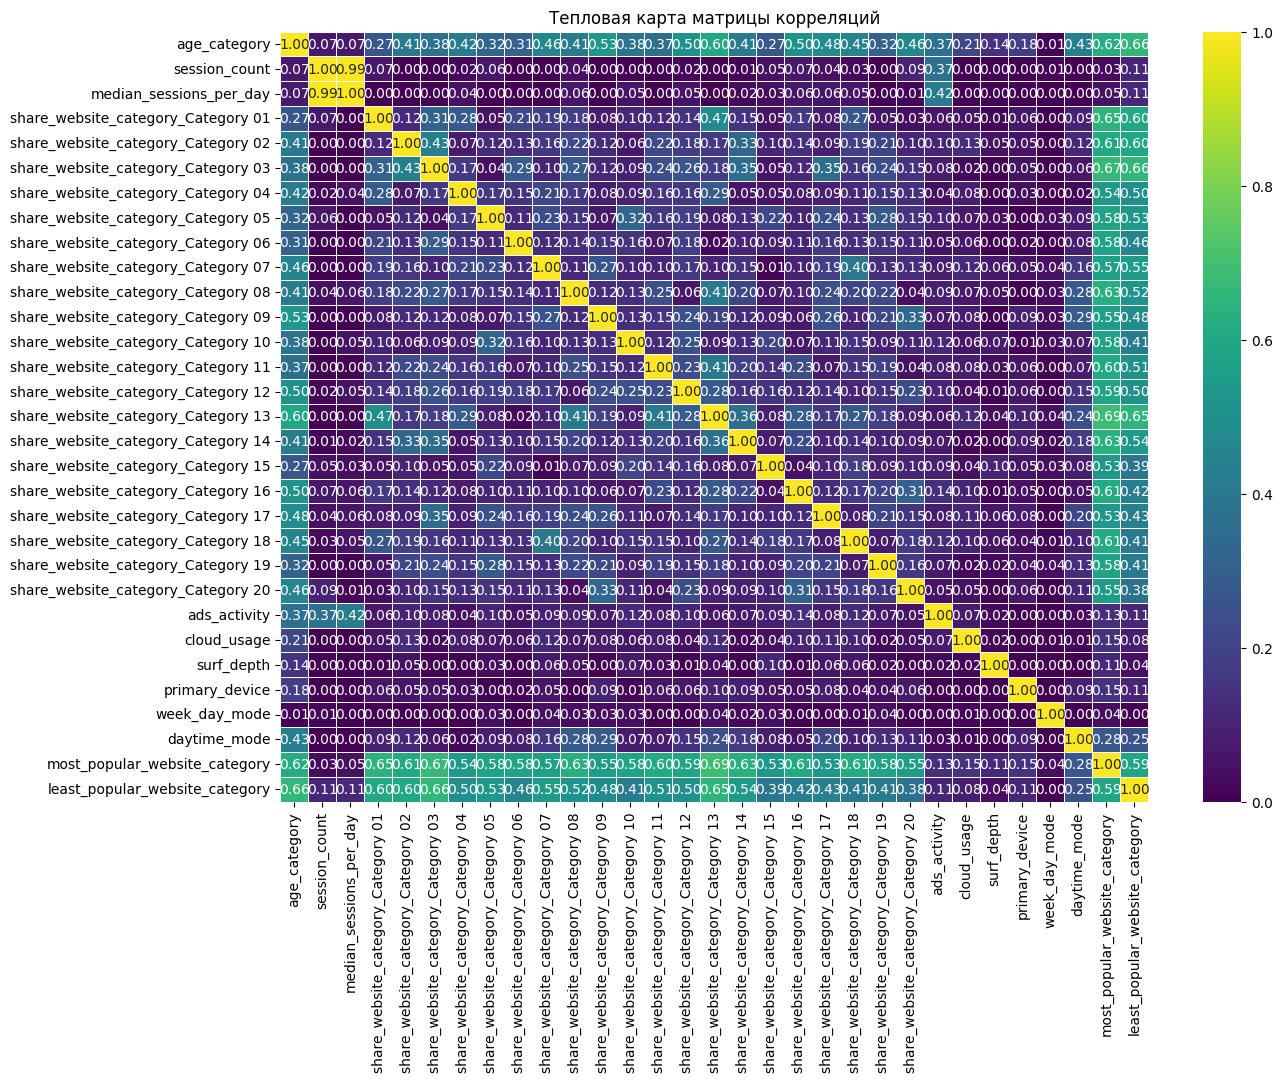

In [35]:
plot_corr_matrix(corr_matrix)

In [36]:
corr_with_target(corr_matrix=corr_matrix, target_col_name='age_category')

age_category                          1.000000
least_popular_website_category        0.658711
most_popular_website_category         0.624123
share_website_category_Category 13    0.595197
share_website_category_Category 09    0.530918
share_website_category_Category 12    0.504003
share_website_category_Category 16    0.503536
share_website_category_Category 17    0.478876
share_website_category_Category 20    0.463448
share_website_category_Category 07    0.456138
share_website_category_Category 18    0.451252
daytime_mode                          0.431162
share_website_category_Category 04    0.416316
share_website_category_Category 08    0.411383
share_website_category_Category 14    0.411280
share_website_category_Category 02    0.409882
share_website_category_Category 10    0.381601
share_website_category_Category 03    0.378157
ads_activity                          0.367874
share_website_category_Category 11    0.366538
share_website_category_Category 05    0.323442
share_website

Анализ:
- наиболее связаны с целевой переменной признаки:  share_website_category_*, least_popular_website_category, most_popular_website_category, daytime_mode, ads_activity, primary_device, cloud_usage - корреляция более 0.15
- наименее связанные с таргетом признаки: session_count, median_sessions_per_day, max_sessions_per_day - кандидаты на удаление. Плюс эти признаки высоко коррелируют между собой.

Рекомендация:
- в пайплайн предобработки встроить фильтрацию по низкой корреляции с таргетом + убирать высоко скоррелированные между собой признаки

### Итог

По таблице visits сформированы агрегированные признаки:
- 'session_count', 'mean_sessions_per_day', 'daytime_mode', 'website_category_mode', 'least_popular_website_category',  'share_website_category_*', 'most_popular_website_category',
- опираясь на корреляционный анализ, можно сделать вывод, что новые признаки полезны для модели. Их корреляция с age_category более 0.4

Общий датафрейм:
- данные объединены в общую таблицу по user_id. После объединения:
    - найдены явные дубли в малочисленные дубликаты (около 5%) были удалены
    - имеются пропуски, которые необходимо заменить в пайплайне статистиками распределений 

Категориальные признаки:
- рекомендация по кодированию: OneHot, если кол-во уникальных значений < 10, иначе Target
- ads_activity, surf_depth по смыслу логично преобразовать в дискретный набор последовательных чисел
- date стоит преобразовать в формат datetime
- website_category - стоит перевести в числовой формат: уникальные значения пронумеровать числами

Числовые признаки:
- сформированы признаки 'session_count', 'median_sessions_per_day' - распределения смещенные, необходимо обрабатывать выбросы. Рекомендуется логарифмировать признаки, чтобы распреления были более симметричными

Целевая переменная:
- классы не сбалансированы, необходимо применять стратификацию при разбиении на test/train

Наиболее перспективные признаки:
- share_website_category_*, daytime_mode, website_category_mode, ads_activity - корреляция с age_category более 0.4

Наименее полезные признаки:
- 'user_id' - не несет полезной информации для анализа
- 'session_count', 'mean_sessions_per_day' - низкая корреляция с таргетом, по результатам корреляционного анализа после разделения выборок скорее всего отфильтреются

## 3. Предобработка данных

### Фильтрация неинформативных признаков

In [37]:
df.duplicated(subset='user_id').sum() # все user_id уникальны

np.int64(0)

In [38]:
df = df.drop(columns='user_id')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 0 to 6145
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age_category                        5826 non-null   int64  
 1   ads_activity                        5593 non-null   object 
 2   cloud_usage                         5680 non-null   object 
 3   surf_depth                          5715 non-null   object 
 4   primary_device                      5669 non-null   object 
 5   week_day_mode                       5826 non-null   object 
 6   session_count                       5826 non-null   int64  
 7   daytime_mode                        5826 non-null   object 
 8   most_popular_website_category       5826 non-null   object 
 9   least_popular_website_category      5826 non-null   object 
 10  median_sessions_per_day             5826 non-null   float64
 11  share_website_category_Category 01  5826 non-nul

#### Преобразование типов

In [40]:
df['ads_activity'] = df['ads_activity'].replace(
    to_replace={'очень редко': 0, 'редко': 1, 'умеренно': 2, 'часто': 3, 'очень часто': 4}).infer_objects()

df['surf_depth'] = df['surf_depth'].replace(
    to_replace={'поверхностно': 0, 'средне': 1, 'глубоко': 2}).infer_objects()


/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_46590/2831343174.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ads_activity'] = df['ads_activity'].replace(
/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_46590/2831343174.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['surf_depth'] = df['surf_depth'].replace(


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 0 to 6145
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age_category                        5826 non-null   int64  
 1   ads_activity                        5593 non-null   float64
 2   cloud_usage                         5680 non-null   object 
 3   surf_depth                          5715 non-null   float64
 4   primary_device                      5669 non-null   object 
 5   week_day_mode                       5826 non-null   object 
 6   session_count                       5826 non-null   int64  
 7   daytime_mode                        5826 non-null   object 
 8   most_popular_website_category       5826 non-null   object 
 9   least_popular_website_category      5826 non-null   object 
 10  median_sessions_per_day             5826 non-null   float64
 11  share_website_category_Category 01  5826 non-nul

In [42]:
NUM_COLS_SPECIAL = ['ads_activity', 'surf_depth', 'cloud_usage']


Итог:
- признаки ads_activity, surf_depth, website_category_mode преобразованы к числовому формату
- стоит учесть, что это дискретные величины при дальнейшем анализе 
- cloud_usage в стоит сперва заменить пропуски на моду, а потом уже преобразовать к int

### Разделение на train/test

In [43]:
X = df.drop(columns=['age_category'])
y = df['age_category']

In [44]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)


X_val, X_train, y_val, y_train = train_test_split(
    X_train_full, y_train_full, test_size=0.75, random_state=RANDOM_SEED, stratify=y_train_full
)

In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_val.shape, y_val.shape

((3495, 30), (1166, 30), (3495,), (1166,), (1165, 30), (1165,))

### Пайплайн предобработки

In [46]:
class ZScoreOutlierReplacer(BaseEstimator, TransformerMixin):
    """Класс фильтрации z-score"""
    def __init__(self, z_threshold: float = 3.0):
        self.z_threshold = z_threshold

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.means_ = np.nanmean(X, axis=0)
        self.stds_ = np.nanstd(X, axis=0)
        self.medians_ = np.nanmedian(X, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()

        safe_stds = np.where(self.stds_ == 0, 1, self.stds_)
        z = np.abs((X - self.means_) / safe_stds)

        outlier_mask = z > self.z_threshold
        X[outlier_mask] = np.take(self.medians_, np.where(outlier_mask)[1])
        return X

    def set_output(self, *, transform=None):
        self._transform_output = transform
        return self
    
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


def replace_zscore_outliers_with_median(z_threshold: float = 3.0):
    return ZScoreOutlierReplacer(z_threshold=z_threshold)

In [47]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Фильтрация признаков по корреляции:
    1. удаляет признаки с низкой корреляцией с целевой переменной;
    2. из пар сильно скоррелированных признаков оставляет тот,
       который сильнее связан с целевой переменной.
    """

    def __init__(self, low_target_threshold=0.05, high_corr_threshold=0.90):
        self.low_target_threshold = low_target_threshold
        self.high_corr_threshold = high_corr_threshold

    def _to_dataframe(self, X, columns=None, index=None):
        
        if isinstance(X, pd.DataFrame):
            return X.copy()

        if columns is None:
            columns = [f'x{i}' for i in range(X.shape[1])]

        return pd.DataFrame(X, columns=columns, index=index)

    def fit(self, X, y):
        """Отбор признаков по корреляции между собой и с целевой переменной."""
        
        # преобразование к нужному формату
        X_df = self._to_dataframe(X)
        self.feature_names_in_ = np.asarray(X_df.columns, dtype=object)
        
        # корреляция с таргетом
        y_series = pd.Series(y, index=X_df.index, name='target')
        target_corr = X_df.corrwith(y_series, method='spearman').abs().fillna(0.0)
        self.target_corr_ = target_corr

        # отбор по порогу
        self.low_corr_features_ = target_corr[
            target_corr < self.low_target_threshold
        ].index.tolist()

        X_filtered = X_df.drop(columns=self.low_corr_features_, errors='ignore')
        self.high_corr_features_ = []
        
        # если признаки еще есть, то фильтруем по корреляции между ними
        if X_filtered.shape[1] > 1:
            # расчет взимной корреляцией
            feature_corr = X_filtered.corr(method='spearman').abs().fillna(0.0)
            upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
            high_corr_pairs = (
                feature_corr.where(upper_mask)
                .stack()
                .reset_index()
                .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
                .query('corr > @self.high_corr_threshold')
                .sort_values('corr', ascending=False)
                .reset_index(drop=True)
            )
            # отбор признаков с высокой взаимной корреляцией
            dropped = set()
            for _, row in high_corr_pairs.iterrows():
                feature_1 = row['feature_1']
                feature_2 = row['feature_2']

                if feature_1 in dropped or feature_2 in dropped:
                    continue

                corr_1 = target_corr.get(feature_1, 0.0)
                corr_2 = target_corr.get(feature_2, 0.0)

                if corr_1 < corr_2:
                    dropped.add(feature_1)
                else:
                    dropped.add(feature_2)
            # список признаков для удаления по причине высокой взаимной корреляции
            self.high_corr_features_ = [col for col in X_filtered.columns if col in dropped]

        cols_to_drop = set(self.low_corr_features_) | set(self.high_corr_features_)
        self.cols_to_drop_ = [col for col in self.feature_names_in_ if col in cols_to_drop]
        return self

    def transform(self, X):
        X_df = self._to_dataframe(X, columns=self.feature_names_in_)
        return X_df.drop(columns=self.cols_to_drop_, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.asarray([col for col in input_features if col not in self.cols_to_drop_], dtype=object)


In [48]:
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    """
    Обёртка над ColumnTransformer, которая:
    - обучает внутренний preprocessor
    - преобразует данные
    - возвращает pd.DataFrame с именами признаков
    """

    def __init__(self, preprocessor):
        self.preprocessor = preprocessor

    def fit(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        self.preprocessor_.fit(X, y)
        self.feature_names_ = self.preprocessor_.get_feature_names_out()
        return self

    def transform(self, X):
        X_transformed = self.preprocessor_.transform(X)

        if sparse.issparse(X_transformed):
            X_transformed = X_transformed.toarray()

        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )

    def fit_transform(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        X_transformed = self.preprocessor_.fit_transform(X, y)
        self.feature_names_ = self.preprocessor_.get_feature_names_out()

        if sparse.issparse(X_transformed):
            X_transformed = X_transformed.toarray()

        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_, dtype=object)


In [49]:
def select_cat_one_hot(X):
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() < 10]

def select_cat_target(X):
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() >= 10]

def select_num_continues(X):
    num_cols_continues = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols_continues if name not in NUM_COLS_SPECIAL]

def select_num_special(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_COLS_SPECIAL]

In [50]:
def create_preprocessing_pipeline(
    with_filtering: bool = True,
    low_target_threshold=0.05,
    high_corr_threshold=0.90
) -> Pipeline:
    """
    Создание пайплайна предобратботки данных.

    Args:
        with_filtering (bool): Включать ли фильтрацию признаков.
    Returns:
        Pipeline: Пайплайн фильтрации и предобработки данных
    """

    # Пайплайны для разных типов признаков
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])

    cat_target_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder(target_type='multiclass'))
    ])

    num_cols_continues_pipeline = Pipeline(steps=[
        ('outliears', replace_zscore_outliers_with_median(z_threshold=3)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])  

    num_special_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler())
    ])

    transformers = [
        ('cat_one_hot', cat_one_hot_pipeline, select_cat_one_hot),
        ('cat_target', cat_target_pipeline, select_cat_target),
        ('num_continues', num_cols_continues_pipeline, select_num_continues),
        ('special', num_special_pipeline, select_num_special),
    ]
    
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    result_pipeline = [
        ('prep', CustomPreprocessor(preprocessor))
    ]
    if with_filtering:
        result_pipeline.append(
            ('corr_filter', CorrelationFilter(  # фильтрация по корреляции
                low_target_threshold=low_target_threshold,
                high_corr_threshold=high_corr_threshold
            ))
        )

    return Pipeline(result_pipeline)


## 4. Обучение и оценка базовой модели

В результате ИАД было определено, что среди целевой переменной наблюдается дисбаланс классов. В качестве основного подхода для решения задачи многоклассовой классификации выбираем **One-vs-Rest**, так как он лучше подходит для несбалансированных данных.

In [51]:
def evaluate_model(y_true, y_pred):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }
    return metrics

def get_result_df(model_names: list[str], metric_dicts: list[dict]):
    # Преобразование результатов в датафрейм
    df_results = pd.DataFrame({
        name: {
            k: v for k, v in metric_dict.items() if k != 'confusion_matrix'
        } for name, metric_dict in zip(model_names, metric_dicts)
    })
    return df_results

In [52]:
def train_test_result_pipeline(pipeline: Pipeline, X_train, y_train, X_val):
    """Обучение пайплайна и формирование предсказания"""
    # Обучаем на тренировочных данных
    pipeline.fit(X_train, y_train)
    # Делаем предсказания на валидационной выборке
    val_preds = pipeline.predict(X_val)
    return  val_preds

### Базовый пайплайн предобработки данных


In [53]:
base_preprocessor = create_preprocessing_pipeline(with_filtering=False)

### Инициализация базовых моделей

In [54]:
# Dummy
dummy_model= DummyClassifier(random_state=RANDOM_SEED)
ovr_dummy = OneVsRestClassifier(estimator=dummy_model)

base_pipeline_dummy = Pipeline([
    ('prep', base_preprocessor),
    ('model', ovr_dummy)
])

# Logreg
base_logreg = LogisticRegression(
    random_state=RANDOM_SEED, class_weight="balanced",
    max_iter=1000, penalty='elasticnet', solver='saga', l1_ratio=0.5
)
ovr_logreg = OneVsRestClassifier(base_logreg)
base_pipeline_ovr_logreg = Pipeline([
    ('prep', base_preprocessor),
    ('model', ovr_logreg)   
])
# Logreg multinomial
logreg_multinomial = LogisticRegression(
    random_state=RANDOM_SEED, 
    multi_class="multinomial",
    penalty='elasticnet', solver='saga', l1_ratio=0.5,
    class_weight="balanced", 
    max_iter=1000
)
pipeline_logreg_multinomial= Pipeline([
    ('prep', base_preprocessor),
    ('model', logreg_multinomial)   
])

# SVC
base_svc = SVC(random_state=RANDOM_SEED, kernel="linear")
ovr_svc = OneVsRestClassifier(base_svc)
base_pipeline_ovr_svc = Pipeline([
    ('prep', base_preprocessor),
    ('model', ovr_svc)   
])

base_pipelines = [
    base_pipeline_dummy,
    base_pipeline_ovr_logreg,
    pipeline_logreg_multinomial,
    base_pipeline_ovr_svc
]

### Обучение

In [55]:
base_model_results = []

for pipeline in base_pipelines:
    val_pred  = train_test_result_pipeline(pipeline=pipeline, X_train=X_train, y_train=y_train, X_val=X_val)
    result = evaluate_model(y_true=y_val, y_pred=val_pred)
    base_model_results.append(result)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide b

### Результаты

### 

In [56]:
base_model_results_df = get_result_df(
    model_names=['dumm_ovr', 'base_logreg_ovr', 'logreg_multinomial', 'base_svc_ovr'],
    metric_dicts=base_model_results
)
base_model_results_df

,dumm_ovr,base_logreg_ovr,logreg_multinomial,base_svc_ovr
accuracy,0.303004,0.799142,0.794850,0.801717
precision_macro,0.060601,0.768812,0.767023,0.771547
recall_macro,0.200000,0.788064,0.788190,0.763819
f1_macro,0.093017,0.775712,0.772735,0.766587


#### Анализ:
- предсказания моделей **BaseLogregOvR** и **BaseSVCOvR** существенно выше **Dummy** классификатора по всем метрикам, что свидетельствует об отсутствии явных ошибок в предобработке данных.


## Создание и отбор признаков

In [57]:
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True, high_corr_threshold=0.9, low_target_threshold=0.01)

### Пайплайны с отбором признаков

In [58]:
# Dummy
dummy_model= DummyClassifier(random_state=RANDOM_SEED, strategy='most_frequent')
ovr_dummy = OneVsRestClassifier(estimator=dummy_model)

filtered_pipeline_dummy = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_dummy)
])

# Logreg
base_logreg = LogisticRegression(
    random_state=RANDOM_SEED,
    class_weight="balanced",
    max_iter=1000,
    penalty="l2",
    solver="lbfgs"
)

ovr_logreg = OneVsRestClassifier(base_logreg)
filtered_pipeline_ovr_logreg = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_logreg)   
])

# Logreg multinomial
logreg_multinomial = LogisticRegression(
    random_state=RANDOM_SEED, 
    multi_class="multinomial",
    solver="lbfgs",
    class_weight="balanced", 
    max_iter=1000
)
filtered_pipeline_logreg_multinomial= Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_multinomial)   
])

# SVC
base_svc = SVC(random_state=RANDOM_SEED, kernel="linear")
ovr_svc = OneVsRestClassifier(base_svc)
filtered_pipeline_ovr_svc = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_svc)   
])

filtered_pipelines = [
    filtered_pipeline_dummy,
    filtered_pipeline_ovr_logreg,
    filtered_pipeline_logreg_multinomial,
    filtered_pipeline_ovr_svc
]

### Обучение

In [59]:
filtered_model_results = []

for pipeline in filtered_pipelines:
    val_pred  = train_test_result_pipeline(pipeline=pipeline, X_train=X_train, y_train=y_train, X_val=X_val)
    result = evaluate_model(y_true=y_val, y_pred=val_pred)
    filtered_model_results.append(result)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a

In [60]:
filtered_model_results_df = get_result_df(
    model_names=['dummy_ovr_flt', 'base_logreg_ovr_flt', 'logreg_multinomial_flt', 'base_svc_ovr_flt'],
    metric_dicts=filtered_model_results
)
filtered_model_results_df

,dummy_ovr_flt,base_logreg_ovr_flt,logreg_multinomial_flt,base_svc_ovr_flt
accuracy,0.303004,0.798283,0.788841,0.802575
precision_macro,0.060601,0.766204,0.760907,0.774717
recall_macro,0.200000,0.785129,0.782338,0.766065
f1_macro,0.093017,0.772710,0.766831,0.769564


In [61]:
pd.merge(base_model_results_df, filtered_model_results_df, left_index=True, right_index=True)

,dumm_ovr,base_logreg_ovr,logreg_multinomial,base_svc_ovr,dummy_ovr_flt,base_logreg_ovr_flt,logreg_multinomial_flt,base_svc_ovr_flt
accuracy,0.303004,0.799142,0.794850,0.801717,0.303004,0.798283,0.788841,0.802575
precision_macro,0.060601,0.768812,0.767023,0.771547,0.060601,0.766204,0.760907,0.774717
recall_macro,0.200000,0.788064,0.788190,0.763819,0.200000,0.785129,0.782338,0.766065
f1_macro,0.093017,0.775712,0.772735,0.766587,0.093017,0.772710,0.766831,0.769564


#### Итог:

- обучены базовые линейные модели многоклассовой классификации с использованием One-vs-Rest стратегии, наилучшим образом подходящей для ситуации с несбалансированными данными.
- BaseLogregOvR, BaseSVCOvR по всем метрикам существенно лучше DummyOvR, что говорит об отсутствии явных ошибок. 
- фильтрация признаков по корреляции несущественно изменила метрики качества моделей. Фильтрацию имеет место применять, поскольку она придает стабильности модели и помогает избегать мультиколлинеарности признаков.
- среди линейных моделей логистическая регрессия и SVC показывают близкие по качеству предсказания


## Подбор гиперпараметров моделей

In [62]:
# Настройка кросс-валидации
N_FOLDS = 5
# классы несбалансированы, применяем стратификацию
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)  

In [63]:
def run_model_grid_search(
    model_name: str,
    pipeline: Pipeline,
    param_grid: list[dict],
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    scoring=['f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=0,
):
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=refit,
        cv=cv,
        n_jobs=n_jobs,
        return_train_score=True,
        verbose=verbose,
    )

    grid_search.fit(X, y)

    results_df = (
        pd.DataFrame(grid_search.cv_results_)
        .sort_values(f'rank_test_{refit}')
    )

    print(f'Модель: {model_name}')
    print(f'Лучшая метрика ({refit}): {grid_search.best_score_:.4f}')
    print('Лучшие параметры:')
    for param_name, param_value in grid_search.best_params_.items():
        print(f'  {param_name}: {param_value}')

    return {
        'model_name': model_name,
        'search': grid_search,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'results_df': results_df,
        'best_estimator': grid_search.best_estimator_,
    }


#### Подбор параметров для OvR LogReg

In [64]:
base_logreg = LogisticRegression(
    random_state=RANDOM_SEED,
    class_weight='balanced',
    max_iter=3000,
)

ovr_logreg = OneVsRestClassifier(base_logreg)

pipeline = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_logreg)
])

logreg_param_grid = [
    {
        'model__estimator__solver': ['lbfgs'],
        'model__estimator__penalty': ['l2'],
        'model__estimator__C': np.logspace(-3, 2, 6),
    },
    {
        'model__estimator__solver': ['saga'],
        'model__estimator__penalty': ['elasticnet'],
        'model__estimator__l1_ratio': [0.25, 0.5, 0.75],
        'model__estimator__C': np.logspace(-3, 1, 5),
    },
]


In [65]:
logreg_grid_result = run_model_grid_search(
    model_name='OvR LogisticRegression',
    pipeline=pipeline,
    param_grid=logreg_param_grid,
    X=X_val,
    y=y_val,
    scoring=['f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    cv=kfold,
)
logreg_grid_result

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

Модель: OvR LogisticRegression
Лучшая метрика (f1_macro): 0.7653
Лучшие параметры:
  model__estimator__C: 1.0
  model__estimator__l1_ratio: 0.5
  model__estimator__penalty: elasticnet
  model__estimator__solver: saga


{'model_name': 'OvR LogisticRegression',
 'search': GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
              estimator=Pipeline(steps=[('prep',
                                         Pipeline(steps=[('prep',
                                                          CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                                           Pipeline(steps=[('imputer',
                                                                                                                                            SimpleImputer(strategy='most_frequent')),
                                                                                                                                           ('encoder',
                                                                                                                                       

In [66]:
logreg_grid_result['best_params'], logreg_grid_result['best_score']

({'model__estimator__C': np.float64(1.0),
  'model__estimator__l1_ratio': 0.5,
  'model__estimator__penalty': 'elasticnet',
  'model__estimator__solver': 'saga'},
 np.float64(0.7653208895361793))

#### Подбор параметров для SVC

In [67]:
base_svc = SVC(
    random_state=RANDOM_SEED,
    class_weight='balanced'
)

ovr_svc = OneVsRestClassifier(base_svc)

pipeline_ovr_svc = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_svc)
])

In [68]:
svc_param_grid = [
    {
        'model__estimator__kernel': ['linear'],
        'model__estimator__C': [0.01, 0.1, 1, 10],
        'model__estimator__class_weight': ['balanced'],
    },
    {
        'model__estimator__kernel': ['rbf'],
        'model__estimator__C': [0.1, 1, 10],
        'model__estimator__gamma': [
            'scale',
            0.01, 0.1, 1
        ],
        'model__estimator__class_weight': ['balanced'],
    },
    {
        'model__estimator__kernel': ['poly'],
        'model__estimator__C': [0.1, 1, 10],
        'model__estimator__gamma': [0.001, 0.01, 0.1],
        'model__estimator__degree': [2, 3, 4],
        'model__estimator__coef0': [0, 0.5, 1],
        'model__estimator__class_weight': ['balanced'],
    },
    {
        'model__estimator__kernel': ['sigmoid'],
        'model__estimator__C': [0.1, 1, 10],
        'model__estimator__gamma': ['scale'],
        'model__estimator__coef0': [-1, 0, 1],
        'model__estimator__class_weight': ['balanced'],
    },
]


In [69]:
svc_grid_result = run_model_grid_search(
    model_name='OvR SVC',
    pipeline=pipeline_ovr_svc,
    param_grid=svc_param_grid,
    X=X_val,
    y=y_val,
    scoring=['f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    cv=kfold,
    n_jobs=-1,
    verbose=1,
)

Fitting 5 folds for each of 106 candidates, totalling 530 fits


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

Модель: OvR SVC
Лучшая метрика (f1_macro): 0.8649
Лучшие параметры:
  model__estimator__C: 1
  model__estimator__class_weight: balanced
  model__estimator__gamma: scale
  model__estimator__kernel: rbf


In [70]:
best_svc = svc_grid_result['best_estimator']
best_params = svc_grid_result['best_params']
best_svc, best_params

(Pipeline(steps=[('prep',
                  Pipeline(steps=[('prep',
                                   CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                    Pipeline(steps=[('imputer',
                                                                                                                     SimpleImputer(strategy='most_frequent')),
                                                                                                                    ('encoder',
                                                                                                                     OneHotEncoder(drop='first',
                                                                                                                                   handle_unknown='ignore',
                                                                                                    

#### Таблица результатов
- топ конфигураций с их метриками.

In [71]:
def get_top_combined_grid_results(
    grid_results: list[dict], 
    top_n: int = 5,
    metrics: list[str] = ['f1_macro', 'precision_macro', 'recall_macro'],
    major_metric: str = 'f1_macro'
) -> pd.DataFrame:
    """Составление топа результатов"""
    combined_results = []

    mean_train_metric_names = [f'mean_train_{i}' for i in metrics]
    mean_test_metric_names = [f'mean_test_{i}' for i in metrics]
    std_train_metric_names = [f'std_train_{i}' for i in metrics]
    std_test_metric_names = [f'std_test_{i}' for i in metrics]
    rank_test_metric_names = [f'rank_test_{i}' for i in metrics]
    tot_names = (['model_name', 'params'] +
        mean_train_metric_names + mean_test_metric_names + 
        std_train_metric_names + std_test_metric_names + rank_test_metric_names
    )

    for grid_result in grid_results:
        model_name = grid_result['model_name']
        results_df = grid_result['results_df'].copy()

        results_df['model_name'] = model_name

        results_df = results_df[tot_names]

        combined_results.append(results_df)

    final_df = pd.concat(combined_results, ignore_index=True)

    final_df = final_df.rename(
        columns={
            f'rank_test_{major_metric}': 'rank_within_model',
            f'mean_test_{major_metric}': f'mean_{major_metric}_test',
            f'std_test_{major_metric}': f'std_{major_metric}_test',
            f'mean_train_{major_metric}': f'mean_{major_metric}_train',
            f'std_train_{major_metric}': f'std_{major_metric}_train',
        }
    )

    final_df = final_df.sort_values(
        by=[f'mean_{major_metric}_test', f'std_{major_metric}_test'],
        ascending=[False, True]
    ).head(top_n).reset_index(drop=True)

    return final_df



In [72]:
top_models = get_top_combined_grid_results(
    grid_results=[logreg_grid_result], 
    top_n=5
)
top_models

,model_name,params,mean_f1_macro_train,mean_train_precision_macro,mean_train_recall_macro,mean_f1_macro_test,mean_test_precision_macro,mean_test_recall_macro,std_f1_macro_train,std_train_precision_macro,std_train_recall_macro,std_f1_macro_test,std_test_precision_macro,std_test_recall_macro,rank_within_model,rank_test_precision_macro,rank_test_recall_macro
0,OvR LogisticRegression,"{'model__estimator__C': 1.0, 'model__estimator...",0.823052,0.816361,0.831974,0.765321,0.761068,0.773242,0.010965,0.011821,0.009430,0.043176,0.041735,0.044127,1,1,1
1,OvR LogisticRegression,"{'model__estimator__C': 1.0, 'model__estimator...",0.821986,0.815514,0.830385,0.763423,0.759266,0.770953,0.012063,0.012621,0.011175,0.038113,0.036926,0.039153,2,2,3
2,OvR LogisticRegression,"{'model__estimator__C': 1.0, 'model__estimator...",0.822763,0.816041,0.831643,0.763011,0.758286,0.772018,0.009365,0.010022,0.008190,0.040010,0.038626,0.040904,3,3,2
3,OvR LogisticRegression,"{'model__estimator__C': 1.0, 'model__estimator...",0.819845,0.813033,0.828768,0.761665,0.757638,0.769455,0.012907,0.013207,0.012363,0.039516,0.038015,0.039972,4,4,4
4,OvR LogisticRegression,"{'model__estimator__C': 10.0, 'model__estimato...",0.820036,0.813454,0.829333,0.756967,0.753118,0.763625,0.011197,0.012220,0.009357,0.047768,0.045680,0.050552,5,5,5


In [73]:
top_svc_models = get_top_combined_grid_results(
    grid_results=[svc_grid_result], 
    top_n=5
)
top_svc_models

,model_name,params,mean_f1_macro_train,mean_train_precision_macro,mean_train_recall_macro,mean_f1_macro_test,mean_test_precision_macro,mean_test_recall_macro,std_f1_macro_train,std_train_precision_macro,std_train_recall_macro,std_f1_macro_test,std_test_precision_macro,std_test_recall_macro,rank_within_model,rank_test_precision_macro,rank_test_recall_macro
0,OvR SVC,"{'model__estimator__C': 1, 'model__estimator__...",0.979717,0.975849,0.983950,0.864945,0.867694,0.863983,0.003581,0.004293,0.002842,0.035746,0.039072,0.032213,1,2,1
1,OvR SVC,"{'model__estimator__C': 1, 'model__estimator__...",0.999500,0.999345,0.999659,0.857509,0.871410,0.848548,0.000678,0.000939,0.000427,0.021541,0.025828,0.019349,2,1,13
2,OvR SVC,"{'model__estimator__C': 10, 'model__estimator_...",0.981296,0.978020,0.984882,0.854130,0.855062,0.854853,0.004100,0.005179,0.002917,0.036666,0.039563,0.033544,3,5,6
3,OvR SVC,"{'model__estimator__C': 10, 'model__estimator_...",1.000000,1.000000,1.000000,0.853510,0.864612,0.846484,0.000000,0.000000,0.000000,0.025626,0.028129,0.024075,4,3,18
4,OvR SVC,"{'model__estimator__C': 0.1, 'model__estimator...",0.998289,0.997778,0.998830,0.852865,0.856154,0.852029,0.001937,0.002685,0.001186,0.037964,0.039549,0.036977,5,4,10


In [74]:
top_svc_models.iloc[0, :]['params']

{'model__estimator__C': 1,
 'model__estimator__class_weight': 'balanced',
 'model__estimator__gamma': 'scale',
 'model__estimator__kernel': 'rbf'}

Анализ:
- модель SVC с нелинейным rbf ядром показало наилучшие метрики: прирост за счет подбора гипер параметров составил около 15% по усредненной по фолдам кросс-валидации f1_macro метрики

Итог:
- используем в дальнейшем классификатор SVC с нелинейным rbf ядром


## Обучение и проверка финальной модели

In [75]:
def get_best_svc(
    top_svc_models: pd.DataFrame, 
    probability: bool = False, 
    random_state: int = RANDOM_SEED) -> SVC:
    best_svc_params = top_svc_models.iloc[0, :]['params']
    return SVC(
        **{k.replace('model__estimator__', ''): v for k, v in best_svc_params.items()},
        probability=probability,
        random_state=random_state
    )

In [76]:
svc_best = get_best_svc(top_svc_models, probability=True)
svc_best

SVC(C=1, class_weight='balanced', probability=True, random_state=42)

In [77]:
preprocessor_filtered = create_preprocessing_pipeline(
    with_filtering=True, 
    high_corr_threshold=0.9, 
    low_target_threshold=0.01
)

pipeline_svc_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_best)
])

#### Расчет метрик на тестовой выборке

In [78]:
def learn_final_pipeline_with_metrics(
    final_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    cv,
    scoring=None,
    major_metric='f1_macro',
):
    """Обучение финального пайплайна и расчет метрик для multiclass-классификации"""

    if scoring is None:
        scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

    cv_results = cross_validate(
        final_pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_means = {
        metric: cv_results[f'test_{metric}'].mean()
        for metric in scoring
    }

    final_pipeline.fit(X_train, y_train)

    y_test_pred = final_pipeline.predict(X_test)

    test_scores = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'f1_macro': f1_score(y_test, y_test_pred, average='macro', zero_division=np.nan),
        'precision_macro': precision_score(y_test, y_test_pred, average='macro', zero_division=np.nan),
        'recall_macro': recall_score(y_test, y_test_pred, average='macro', zero_division=np.nan),
    }

    result = pd.DataFrame({
        'metric': scoring,
        'cv_mean': [cv_means[metric] for metric in scoring],
        'test_score': [test_scores[metric] for metric in scoring],
    })

    result['difference, %'] = (
        (result['test_score'] - result['cv_mean']) / result['test_score'] * 100
    ).round(2)

    print(f'Основная метрика: {major_metric}')
    print(f'CV mean: {cv_means[major_metric]:.4f}')
    print(f'Test score: {test_scores[major_metric]:.4f}')

    print('\nClassification report:')
    print(classification_report(y_test, y_test_pred, zero_division=0))

    return {
        'pipeline': final_pipeline,
        'metrics': result,
        'classification_report': classification_report(
            y_test,
            y_test_pred,
            zero_division=0,
            output_dict=True,
        ),
        'confusion_matrix': confusion_matrix(y_test, y_test_pred),
        'y_test_pred': y_test_pred,
    }

In [79]:
def plot_conf_matrix(cm: np.ndarray):
    fig, ax = plt.subplots(figsize=(15,8))

    # Визуализируем матрицу на тепловой карте
    ax = sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.show()

In [80]:
result_metrics = learn_final_pipeline_with_metrics(
    final_pipeline=pipeline_svc_best,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=kfold,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    major_metric='f1_macro',
)
result_metrics['metrics']

Основная метрика: f1_macro
CV mean: 0.8792
Test score: 0.8871

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       171
           1       0.74      0.77      0.75       103
           2       0.89      0.90      0.90       288
           3       0.94      0.93      0.94       251
           4       0.96      0.93      0.95       353

    accuracy                           0.91      1166
   macro avg       0.88      0.89      0.89      1166
weighted avg       0.91      0.91      0.91      1166



,metric,cv_mean,test_score,"difference, %"
0,accuracy,0.898426,0.908233,1.08
1,f1_macro,0.879169,0.887050,0.89
2,precision_macro,0.873678,0.883564,1.12
3,recall_macro,0.887157,0.891039,0.44


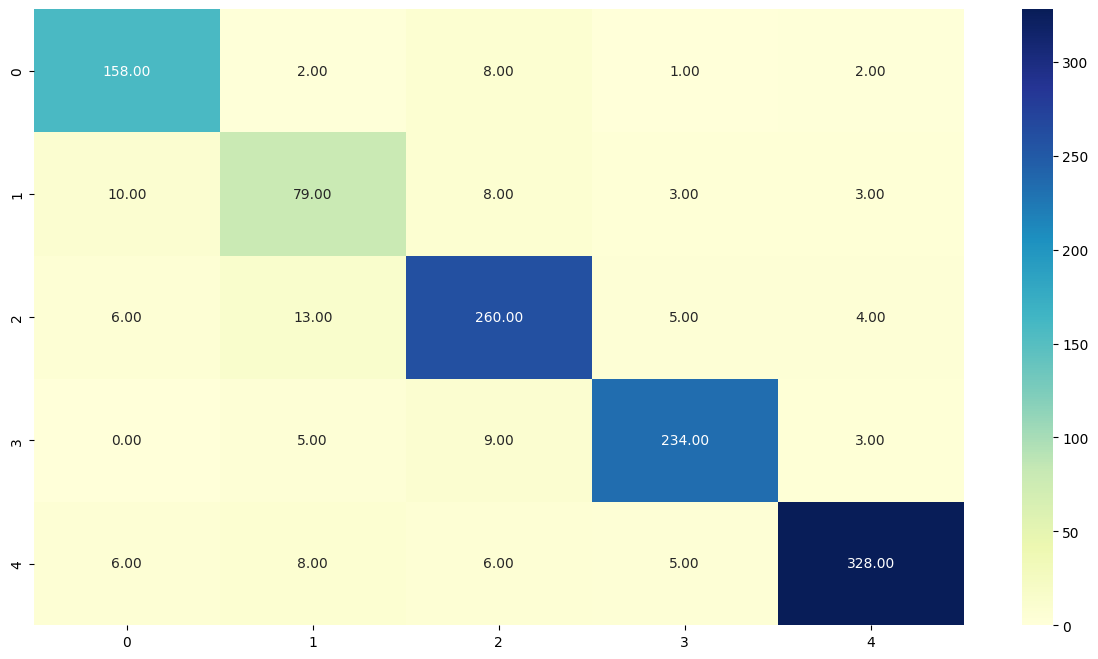

In [81]:
plot_conf_matrix(result_metrics['confusion_matrix'])

#### Анализ итоговой модели
- прослеживается четкая зависимость качества предсказаний от количества объектов в заданном классе: чем больше объектов, тем предсказания лучше (ключевая метрика выше)
- хуже всего модель предсказывает самый малочисленный 1 класс: f1-score = 0.82
- лучше всего самый многочисленный 4 класс: f1-score = 0.93
- модель уверенно отделяет классы: элементы на диагонали матрицы ошибок существенно превосходят по значению внедиагональные элементы
- общая точность предсказаний довольно высокая: accuracy = 0.9. 
- макро усреднение показывает, что для различных по количеству объектов классов в среднем предсказания довольно точные: f1_macro=0.88
- разница по ключевым метрикам на test и train несущественная: в пределах 1%. Это свидетельствует об отсутствии переобучения модели и хорошей предсказательной способности 


#### Анализ наиболее важный признаков 

In [82]:
def get_original_feature_name(feature_name: str) -> str:
    """Получить исходные названия столбцов до кодирования"""
    if feature_name.startswith('cat_one_hot__'):
        return feature_name.split('__', 1)[1].rsplit('_', 1)[0]
    if '__' in feature_name:
        return feature_name.split('__', 1)[1]
    return feature_name

In [83]:
def get_important_features_permutation(
    pipeline: Pipeline,
    X,
    y,
    top_n: int = 10,
    scoring: str = 'f1_macro',
    n_repeats: int = 10,
    random_state: int = RANDOM_SEED,
    n_jobs: int = -1,
) -> pd.DataFrame:
    """
    Model-agnostic важность признаков через permutation importance.
    Подходит для SVC с rbf/poly/sigmoid kernel.
    
    Важно: pipeline должен быть уже обучен.
    """

    result = permutation_importance(
        estimator=pipeline,
        X=X,
        y=y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs,
    )

    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    })

    feature_importance = (
        feature_importance
        .sort_values(by='importance_mean', ascending=False)
        .reset_index(drop=True)
    )

    return feature_importance.head(top_n)

In [84]:
top_important_feat_svc = get_important_features_permutation(
    pipeline=result_metrics['pipeline'],
    X=X_val,
    y=y_val,
    top_n=10,
    scoring='f1_macro',
    n_repeats=10,
)

top_important_feat_svc

,feature,importance_mean,importance_std
0,share_website_category_Category 13,0.047302,0.008751
1,share_website_category_Category 18,0.038449,0.003784
2,share_website_category_Category 08,0.036353,0.006668
3,share_website_category_Category 16,0.032727,0.005597
4,daytime_mode,0.028658,0.004560
5,share_website_category_Category 20,0.025721,0.003806
6,share_website_category_Category 12,0.022865,0.006071
7,share_website_category_Category 15,0.018757,0.005185
8,share_website_category_Category 07,0.017580,0.004792
9,share_website_category_Category 14,0.017006,0.003698


Анализ:
- наиболее важные признки 
    - share_website_category_*: доли сайтов, посещаемых каждым пользователем
- важность этих признаков можно объяснить тем, что различные возрастные категории предпочитают различные категории контента 



## Подготовка артефактов модели для внедрения

Лучшая модель

In [85]:
pipeline_best = result_metrics['pipeline']
pipeline_best

Pipeline(steps=[('prep',
                 Pipeline(steps=[('prep',
                                  CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                   Pipeline(steps=[('imputer',
                                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                                   ('encoder',
                                                                                                                    OneHotEncoder(drop='first',
                                                                                                                                  handle_unknown='ignore',
                                                                                                                                  sparse_output=False))]),
                                                                                                   <function select_cat_one_hot at 0x173d4adc0>),
                                                                                                  ('cat_target',
                                                                                                   Pipeline(ste...
                                                                                                                    StandardScaler())]),
                                                                                                   <function select_num_continues at 0x173d89c10>),
                                                                                                  ('special',
                                                                                                   Pipeline(steps=[('imputer',
                                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                                   ('scaler',
                                                                                                                    MinMaxScaler())]),
                                                                                                   <function select_num_special at 0x173d89ca0>)]))),
                                 ('corr_filter',
                                  CorrelationFilter(low_target_threshold=0.01))])),
                ('model',
                 SVC(C=1, class_weight='balanced', probability=True,
                     random_state=42))])

Сохранение:

In [86]:
def create_df(names: list[str], data_frames: list[pd.DataFrame]) -> pd.DataFrame:
    """Формирования общего датасета"""
    # общий датасет
    names_df_dict = dict(zip(names, data_frames))

    df = create_dataset(names_df_dict)

    # чистка дублей
    df = df.drop_duplicates()
    # убираем неинформативные признаки
    df = df.drop(columns='user_id', errors='ignore')

    # преобразование типов
    df['ads_activity'] = df['ads_activity'].replace({
        'очень редко': 0,
        'редко': 1,
        'умеренно': 2,
        'часто': 3,
        'очень часто': 4
    }).infer_objects()

    df['surf_depth'] = df['surf_depth'].replace({
        'поверхностно': 0,
        'средне': 1,
        'глубоко': 2
    }).infer_objects()

    return df


In [93]:
# сохранение артефактов

# функция создания единого датафрейма
joblib.dump(create_df, 'create_df.joblib')

# обученный пайплайн с лучшей моделью
joblib.dump(pipeline_best, 'pipeline_best.joblib')

['pipeline_best.joblib']

### Проверка корректного сохранения артефактов

In [94]:
# загрузка 
loaded_pipeline = joblib.load('pipeline_best.joblib')
loaded_df_creator = joblib.load('create_df.joblib')

In [95]:
data_paths = [
    'https://code.s3.yandex.net/datasets/ds_s13_users.csv',
    'https://code.s3.yandex.net/datasets/ds_s13_visits.csv',
    'https://code.s3.yandex.net/datasets/ads_activity.csv',
    'https://code.s3.yandex.net/datasets/surf_depth.csv',
    'https://code.s3.yandex.net/datasets/primary_device.csv',
    'https://code.s3.yandex.net/datasets/cloud_usage.csv'
]
data_frames = [pd.read_csv(path) for path in data_paths]
names = ['users', 'visits', 'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']

In [96]:
# Пример загрузки и формирования единого датасета
df = loaded_df_creator(names, data_frames)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 0 to 6145
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age_category                        5826 non-null   int64  
 1   week_day_mode                       5826 non-null   object 
 2   session_count                       5826 non-null   int64  
 3   daytime_mode                        5826 non-null   object 
 4   most_popular_website_category       5826 non-null   object 
 5   least_popular_website_category      5826 non-null   object 
 6   median_sessions_per_day             5826 non-null   float64
 7   share_website_category_Category 01  5826 non-null   float64
 8   share_website_category_Category 02  5826 non-null   float64
 9   share_website_category_Category 03  5826 non-null   float64
 10  share_website_category_Category 04  5826 non-null   float64
 11  share_website_category_Category 05  5826 non-nul

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_46590/2699586511.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ads_activity'] = df['ads_activity'].replace({
/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_46590/2699586511.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['surf_depth'] = df['surf_depth'].replace({


- формирование датасета прошло успешно

In [97]:
# пример предсказания модели
y_pred = loaded_pipeline.predict(X_test)

In [98]:
y_pred

array([4, 2, 4, ..., 4, 4, 2])

- модель отработала успешно, предсказания классов получены

## Выводы о результатах работы

Разработана модель, позволяющая определять возрастную категорию пользователей сайтов по анонимизированной информации.

ИАД:

- В ходе исследовательского анализа данных было выявлено, что данные содержат пропуски и дубликаты. Ошибки в данных были обработаны: дубли устранены, а пропуски заменены на статистики распределений после разделения на train/test. 


Формирование новых признаков:
- проведена агрегация данных в таблице visits, созданы новые признаки для каждого уникального пользователя
- сформирована общая таблица признаков

Проведен отбор признаков по корреляции: 
- признаки с малым показателем корреляции с целевой категорией были удалены, 
- сильно скоррелированные между собой признаки отфильтрованы так: среди сильно скоррелированных отброшены те, которые меньше скоррелированы с целевой переменной
- в результате фильтрации признаков качество базовой модели практически не изменилось (менее 1% изменение по ключевой метрике). Стоит отметить, что фильтрация все же полезна, поскольку снижает вычислительные затраты на обучения и делает модели более стабильными (помогает уйти от мультиколлинеарности)


Подбор гиперпараметров:
- проведен отбор гиперпараметров на валидационной выборке
- отбор гиперпараметров моделей позволил повысить ключую метрику предсказания более чем на 15%
- была выявлена наилучшая модель: OvR SVC с нелинейный rdf ядром.

Ключевые признаки:
- наиболее важными признаками оказались доли посещений сайтов по категориям, а также наиболее популярное время дня для поседещения сайтов. Эта сегментация легко объясняется: 
- люди разных возрастов потребляют различные категории контента - по ним и стоит разделять возрастные группы. 
- люди разных возрастов имеют привычку заходить на сайты в разное время дня: взрослые больше утром, молодежь ближе к вечеру


Итоговая модель:
- наилучшая модель на тестовой выборке показала хорошую предсказательную способность: ключевая метрика f1_macro=0.86. При этом разница между train и test в пределах 2%, что говорит об отсутствии переобучения
- итоговый пайплайн обучения был сохранен в файл 

